<a href="https://colab.research.google.com/github/hortonllc6-coder/Agentic-Trace/blob/main/Agentic_Trace_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import time
import uuid
from typing import Dict, Any, List

class AgentTrace:
    def __init__(self, model_name: str):
        self.model_name = model_name
        self.traces = []

    def capture_step(self, agent_name: str, input_text: str, output_text: str, metadata: Dict[str, Any]):
        """
        Captures a single 'thought' or action from an agent.
        """
        trace_id = str(uuid.uuid4())
        timestamp = time.time()

        trace_entry = {
            "trace_id": trace_id,
            "timestamp": timestamp,
            "agent": agent_name,
            "model": self.model_name,
            "input": input_text,
            "output": output_text,
            "latency": metadata.get("latency"),
            "tokens": metadata.get("tokens"),
            "confidence_score": self._calculate_confidence(output_text) # Placeholder for Phase 2
        }

        self.traces.append(trace_entry)
        return trace_id

    def _calculate_confidence(self, text: str) -> float:
        # Phase 2 will involve using a 'Judge' LLM to score this
        return 0.95

    def get_report(self) -> List[Dict]:
        return self.traces

        # 1. Instantiate the class (Create the object)
tracer = AgentTrace(model_name="GPT-4")

# 2. Call a method (The action)
tracer.capture_step(
    agent_name="SearchBot",
    input_text="What is the weather in Atlanta?",
    output_text="It is 70 degrees and sunny.",
    metadata={"tokens": 12, "latency": 0.5}
)

# 3. Print the result so you can see it in Colab
print(tracer.get_report())

[{'trace_id': '8a8d0114-c88f-4ed6-915a-c79e2b12eed4', 'timestamp': 1774370855.87627, 'agent': 'SearchBot', 'model': 'GPT-4', 'input': 'What is the weather in Atlanta?', 'output': 'It is 70 degrees and sunny.', 'latency': 0.5, 'tokens': 12, 'confidence_score': 0.95}]


In [6]:
class AgentJudge:
    def __init__(self, judge_model="GPT-4o-mini"):
        self.judge_model = judge_model

    def evaluate_factuality(self, trace_log: Dict):
        """
        Simulates an LLM-as-a-Judge checking the output.
        """
        # In a real project, you'd send 'input' and 'output' to an LLM here.
        # For now, let's write the logic that flags 'low confidence' traces.

        input_text = trace_log['input']
        output_text = trace_log['output']

        # Logic: If the output is too short, mark it as 'Low Detail'
        is_detailed = len(output_text.split()) > 5

        return {
            "trace_id": trace_log['trace_id'],
            "passed_audit": is_detailed,
            "audit_note": "Detail check passed" if is_detailed else "Flag: Response too short"
        }

# --- TEST IT ---
judge = AgentJudge()
report = tracer.get_report()[0] # Get that first log you just created
audit_result = judge.evaluate_factuality(report)
print(audit_result)

{'trace_id': '8a8d0114-c88f-4ed6-915a-c79e2b12eed4', 'passed_audit': True, 'audit_note': 'Detail check passed'}


In [7]:
import random

# 1. Define our "Synthetic Data" parameters
cities = ["Atlanta", "NYC", "London", "Tokyo", "Cape Town"]
moods = ["impatient", "friendly", "confused", "formal"]

# 2. The Simulation Loop
print(f"🚀 Starting simulation of 100 test cases...\n")

for i in range(100):
    # Generate a random scenario
    city = random.choice(cities)
    mood = random.choice(moods)

    # Create a dynamic prompt based on the persona
    if mood == "impatient":
        query = f"Hurry up and tell me the weather in {city} now!"
    elif mood == "confused":
        query = f"I think I'm in {city}, what's it like outside? Is it raining?"
    else:
        query = f"Could you please provide the weather for {city}?"

    # Simulate the LLM response (In a real app, this is where you'd call the API)
    # We'll intentionally make 10% of them "fail" (too short) to test our Judge
    if i % 10 == 0:
        simulated_response = "Rain." # Short failure case
    else:
        simulated_response = f"The weather in {city} is currently 72°F and perfect for a walk."

    # 3. Trace the "thought"
    trace_id = tracer.capture_step(
        agent_name=f"Agent_{mood}",
        input_text=query,
        output_text=simulated_response,
        metadata={"tokens": random.randint(10, 50), "latency": random.uniform(0.1, 0.8)}
    )

print(f"✅ Simulation Complete. {len(tracer.get_report())} total traces captured.")

🚀 Starting simulation of 100 test cases...

✅ Simulation Complete. 101 total traces captured.


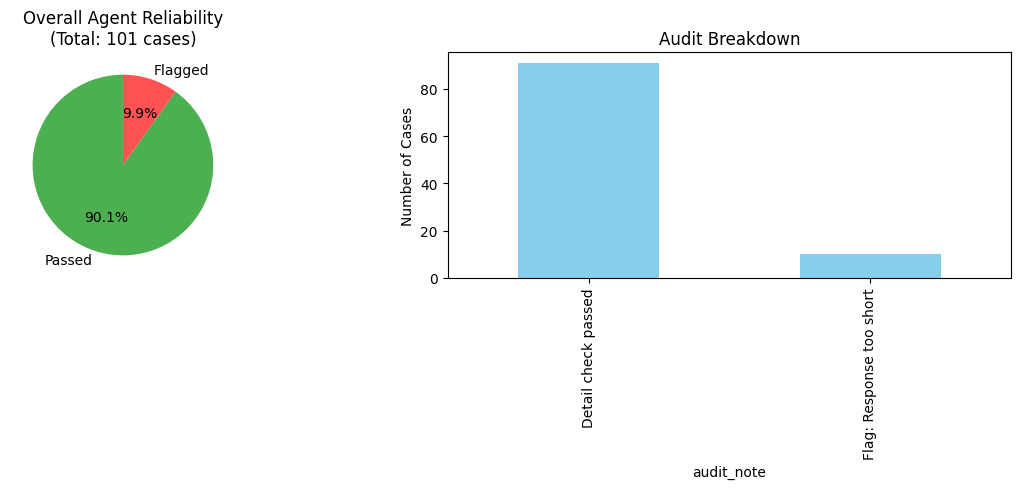


📈 FINAL REPORT:
-------------------
Success Rate: 90.10%
Status: ✅ PRODUCTION READY


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Process all captured traces through the Judge
audit_results = [judge.evaluate_factuality(t) for t in tracer.get_report()]

# 2. Convert to a DataFrame for easy analysis
df = pd.DataFrame(audit_results)
total_cases = len(df)
passed = df['passed_audit'].sum()
failed = total_cases - passed
success_rate = (passed / total_cases) * 100

# 3. Create the Visual Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Success vs Failure (Pie)
ax1.pie([passed, failed], labels=['Passed', 'Flagged'], autopct='%1.1f%%', colors=['#4CAF50', '#FF5252'], startangle=90)
ax1.set_title(f"Overall Agent Reliability\n(Total: {total_cases} cases)")

# Chart 2: Audit Notes Distribution (Bar)
df['audit_note'].value_counts().plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_title("Audit Breakdown")
ax2.set_ylabel("Number of Cases")

plt.tight_layout()
plt.show()

print(f"\n📈 FINAL REPORT:")
print(f"-------------------")
print(f"Success Rate: {success_rate:.2f}%")
print(f"Status: {'✅ PRODUCTION READY' if success_rate > 90 else '⚠️ NEEDS ITERATION'}")
